In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('AI_Impact_on_Jobs_2030.csv')
# First 5 rows
print(df.head())

# Dataset information
print("\nDataset Information:")
print(df.info())

# Shape of dataset
print("\nShape of Dataset:")
print(df.shape)

# Statistical summary
print("\nStatistical Summary:")
print(df.describe())

print("\nMissing Values:")
print(df.isnull().sum())

  Employee_ID              Job_Title    Industry Country Education_Level  \
0  AIJ-100000          Data Engineer  Healthcare   Japan             PhD   
1  AIJ-100001     Healthcare Analyst      Retail      UK        Bachelor   
2  AIJ-100002          HR Specialist   Education  Canada     High School   
3  AIJ-100003  Cybersecurity Analyst  Government      UK        Bachelor   
4  AIJ-100004     Healthcare Analyst   Education     UAE             PhD   

   Years_Experience  AI_Replacement_Risk  Future_Demand_Score  \
0                 1                 0.25                 0.78   
1                24                 0.73                 0.33   
2                21                 0.80                 0.69   
3                 5                 0.29                 0.94   
4                20                 0.11                 0.92   

  Remote_Work_Possibility  Average_Salary_USD  \
0                     Yes              207392   
1                      No              140785   
2    

In [3]:
print("\nDuplicate Rows:")
print(df.duplicated().sum())


Duplicate Rows:
0


In [4]:
df.drop(columns = ['Employee_ID'],inplace = True)

In [5]:
numerical_cols = df.select_dtypes(include=np.number).columns
categorical_cols = df.select_dtypes(include='object').columns

print("\nNumerical Columns:")
print(numerical_cols)

print("\nCategorical Columns:")
print(categorical_cols)


Numerical Columns:
Index(['Years_Experience', 'AI_Replacement_Risk', 'Future_Demand_Score',
       'Average_Salary_USD', 'Job_Growth_2030', 'Work_Hours_Per_Week',
       'Performance_Score', 'Job_Satisfaction'],
      dtype='object')

Categorical Columns:
Index(['Job_Title', 'Industry', 'Country', 'Education_Level',
       'Remote_Work_Possibility', 'Required_Skills', 'Automation_Level',
       'Company_Size', 'AI_Tool_Usage', 'Upskilling_Needed',
       'Hiring_Trend_2026'],
      dtype='object')


In [6]:
z_scores = df[numerical_cols].apply(
    lambda x: (x - x.mean()) / x.std()
)

threshold = 3

outliers = df[(np.abs(z_scores) > threshold).any(axis=1)]

print("Total outliers:", outliers.shape[0])
print(outliers.head())

Total outliers: 0
Empty DataFrame
Columns: [Job_Title, Industry, Country, Education_Level, Years_Experience, AI_Replacement_Risk, Future_Demand_Score, Remote_Work_Possibility, Average_Salary_USD, Required_Skills, Automation_Level, Job_Growth_2030, Work_Hours_Per_Week, Company_Size, AI_Tool_Usage, Performance_Score, Upskilling_Needed, Job_Satisfaction, Hiring_Trend_2026]
Index: []


In [7]:
Q1 = df['Average_Salary_USD'].quantile(0.25)
Q3 = df['Average_Salary_USD'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[
    (df['Average_Salary_USD'] < lower_bound) |
    (df['Average_Salary_USD'] > upper_bound)
]

print("Number of outliers:", len(outliers))

Number of outliers: 0


In [8]:
for colname in categorical_cols:
    print(f'{colname} : {len(df[colname].unique())}')

Job_Title : 20
Industry : 10
Country : 10
Education_Level : 4
Remote_Work_Possibility : 3
Required_Skills : 2937
Automation_Level : 3
Company_Size : 3
AI_Tool_Usage : 3
Upskilling_Needed : 2
Hiring_Trend_2026 : 3


In [9]:
from sklearn.feature_extraction.text import CountVectorizer

cv = CountVectorizer(
    tokenizer=lambda x: x.split(', '),
    token_pattern=None
)

X = cv.fit_transform(df['Required_Skills'])

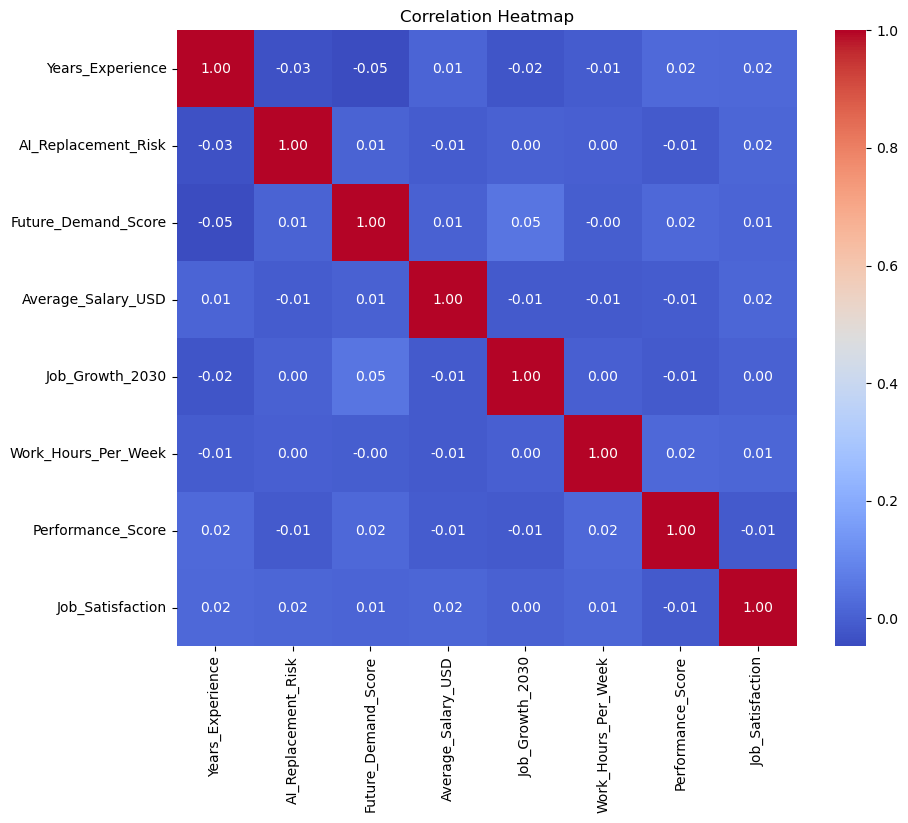

In [9]:
# ===========================
# 6. Correlation Heatmap
# ===========================

plt.figure(figsize=(10, 8))
sns.heatmap(df[numerical_cols].corr(),
            annot=True,
            cmap='coolwarm',
            fmt='.2f')

plt.title('Correlation Heatmap')
plt.show()


In [10]:
# ===========================
# 11. Label Encoding
# ===========================

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

label_cols = [
    'Education_Level',
    'Automation_Level',
    'AI_Tool_Usage',
    'Country',
    'Hiring_Trend_2026',
    'Job_Title',
    'Industry',
    'Remote_Work_Possibility',
    'Company_Size',
    'Upskilling_Needed'
]

for col in label_cols:
    df[col] = le.fit_transform(df[col])

In [12]:
# ===========================
# 12. One-Hot Encoding
# ===========================

onehot_cols = [
    
]

df = pd.get_dummies(
    df,
    columns=onehot_cols,
    drop_first=True
)

In [11]:
# ===========================
# 13. Feature Scaling
# ===========================

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scale_cols = [
    'Years_Experience',
    'Average_Salary_USD',
    'Work_Hours_Per_Week',
    'Job_Growth_2030',
]
df[scale_cols] = scaler.fit_transform(df[scale_cols])

# ===========================
# 14. Final Dataset
# ===========================

print("\nFinal Dataset Shape:")
print(df.shape)

print("\nPreprocessed Dataset:")
print(df.head())


Final Dataset Shape:
(3000, 19)

Preprocessed Dataset:
   Job_Title  Industry  Country  Education_Level  Years_Experience  \
0          5         4        4                3         -1.512148   
1         11         7        8                0          1.543233   
2         10         0        1                1          1.144705   
3          4         3        8                0         -0.980777   
4         11         0        7                3          1.011862   

   AI_Replacement_Risk  Future_Demand_Score  Remote_Work_Possibility  \
0                 0.25                 0.78                        2   
1                 0.73                 0.33                        1   
2                 0.80                 0.69                        2   
3                 0.29                 0.94                        1   
4                 0.11                 0.92                        1   

   Average_Salary_USD                                    Required_Skills  \
0            1

In [12]:
df.isnull().sum()

Job_Title                  0
Industry                   0
Country                    0
Education_Level            0
Years_Experience           0
AI_Replacement_Risk        0
Future_Demand_Score        0
Remote_Work_Possibility    0
Average_Salary_USD         0
Required_Skills            0
Automation_Level           0
Job_Growth_2030            0
Work_Hours_Per_Week        0
Company_Size               0
AI_Tool_Usage              0
Performance_Score          0
Upskilling_Needed          0
Job_Satisfaction           0
Hiring_Trend_2026          0
dtype: int64

In [13]:
from sklearn.preprocessing import MultiLabelBinarizer

df['Required_Skills'] = df['Required_Skills'].str.split(', ')

mlb = MultiLabelBinarizer()

skills_df = pd.DataFrame(
    mlb.fit_transform(df['Required_Skills']),
    columns=mlb.classes_,
    index=df.index
)

df = pd.concat([df.drop('Required_Skills', axis=1), skills_df], axis=1)

In [14]:
df.to_csv('ai_impact_on_jobs_cleaned.csv')